


#Dataset Loading

SEEDING

In [ ]:
import os
import random
import numpy as np
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
def seed_everything(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Flower / Ray stability
    os.environ["RAY_DISABLE_IMPORT_WARNING"] = "1"

SEED = 42
seed_everything(SEED)


Data Path

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Fs/final_feature_label_dataset_normalized_interpolated.xlsx"


Data Ordering

In [ ]:
df = pd.read_excel(DATA_PATH)

df = df.sort_values(
    by=["person", "session", "window_start"],
    ascending=True
).reset_index(drop=True)

print("Persons:", df.person.nunique())
print("Sessions:", df.session.nunique())
print("Total rows:", len(df))


Persons: 12
Sessions: 3
Total rows: 2819


Columns isolation

In [ ]:
META_COLS = ["person", "session", "window_start"]
LABEL_COLS = ["physicalFatigueScore", "mentalFatigueScore"]


Feature cols

In [ ]:
FEATURE_COLS = [
    "hr_mean", "hr_std",
    "duration_mean", "duration_std",
    "ax_mean", "ax_std",
    "ay_mean", "ay_std",
    "az_mean", "az_std",
    "eda_mean", "eda_std",
    "temp_mean", "temp_std"
]


Assertion

In [ ]:
assert not any(c in FEATURE_COLS for c in META_COLS)
assert not any(c in FEATURE_COLS for c in LABEL_COLS)


In [ ]:
X = df[FEATURE_COLS].values
y = df[LABEL_COLS].values

In [ ]:
clients_raw = {}

for person_id, g in df.groupby("person", sort=False):
    clients_raw[person_id] = {
        "X": g[FEATURE_COLS].values.astype(np.float32),
        "y": g[LABEL_COLS].values.astype(np.float32)
    }

print("Federated clients:", len(clients_raw))


Federated clients: 12


Normalization

In [ ]:
def normalize_client(X, split_ratio=0.8):
    scaler = StandardScaler()

    split = int(len(X) * split_ratio)

    # Fit ONLY on earlier windows
    X_train = scaler.fit_transform(X[:split])
    X_test  = scaler.transform(X[split:])

    return X_train, X_test


Client Dataset

In [ ]:
class FatigueClientDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


Train Test Split

In [ ]:
client_datasets = {}

for pid, data in clients_raw.items():
    X = data["X"]
    y = data["y"]

    X_train, X_test = normalize_client(X)
    split = int(len(y) * 0.8)

    y_train = y[:split]
    y_test  = y[split:]

    client_datasets[pid] = {
        "train": FatigueClientDataset(X_train, y_train),
        "test":  FatigueClientDataset(X_test, y_test)
    }


In [ ]:
# ============================================================
# FIX: Define client ↔ person mapping for Flower
# ============================================================

PERSON_IDS = sorted(list(client_datasets.keys()))
NUM_CLIENTS = len(PERSON_IDS)

INPUT_DIM = len(FEATURE_COLS)

print("PERSON_IDS:", PERSON_IDS)
print("NUM_CLIENTS:", NUM_CLIENTS)
print("INPUT_DIM:", INPUT_DIM)


PERSON_IDS: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
NUM_CLIENTS: 12
INPUT_DIM: 14


Client Loaders

In [ ]:
def get_client_loaders(person_id, batch_size=32):
    # <<< FIX: separate loaders
    train_loader = DataLoader(
        client_datasets[person_id]["train"],
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    test_loader = DataLoader(
        client_datasets[person_id]["test"],
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    return train_loader, test_loader


In [ ]:
import torch
import torch.nn as nn

Flower cli

In [ ]:
# !pip uninstall -y flwr ray protobuf
# !pip install "protobuf>=4.21.0,<5.0.0"
# !pip install "ray==2.31.0"
# !pip install "flwr==1.10.0"


In [ ]:
import sys
import flwr as fl
import ray
import google.protobuf
import numpy as np

print(sys.version)
print("Flower:", fl.__version__)
print("Ray:", ray.__version__)
print("Protobuf:", google.protobuf.__version__)
print("NumPy:", np.__version__)


3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Flower: 1.10.0
Ray: 2.31.0
Protobuf: 4.25.8
NumPy: 1.26.4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Functions - Train and Evaluate

In [ ]:
DEVICE = torch.device("cpu")

def train(model, loader, epochs=2, lr=1e-3):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.MSELoss()

    for _ in range(epochs):
        for X, y in loader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()
            preds = model(X)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(model, loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            preds = model(X)

            y_true.append(y.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    mae = mean_absolute_error(y_true, y_pred)

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2



Function - Weighted Average

In [ ]:
def weighted_average(metrics):
    total = sum(num_examples for num_examples, _ in metrics)
    return {
        "mae":  sum(num_examples * m["mae"]  for num_examples, m in metrics) / total,
        "rmse": sum(num_examples * m["rmse"] for num_examples, m in metrics) / total,
        "r2":   sum(num_examples * m["r2"]   for num_examples, m in metrics) / total,
    }

Results Saver

In [ ]:
# ======================= METRIC LOGGER (SERVER-SIDE) =======================

import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/Fs/FL_Results_1"   # change if needed

# ======================= METRIC LOGGER (FIXED) =======================

def _list_to_dict(metric_list):
    """
    Converts [(round, value), ...] → {round: value}
    """
    return {int(r): float(v) for r, v in metric_list}


def save_fl_history(history, algo_name: str, model_name: str):
    """
    Saves aggregated RMSE / MAE / R2 per round from Flower History.

    Compatible with Flower >= 1.0
    """

    os.makedirs(BASE_DIR, exist_ok=True)
    algo_dir = os.path.join(BASE_DIR, algo_name)
    os.makedirs(algo_dir, exist_ok=True)

    # ---- Convert Flower lists → dicts
    rmse_dict = _list_to_dict(history.metrics_distributed.get("rmse", []))
    mae_dict  = _list_to_dict(history.metrics_distributed.get("mae", []))
    r2_dict   = _list_to_dict(history.metrics_distributed.get("r2", []))

    rounds = sorted(rmse_dict.keys())

    rows = []
    for r in rounds:
        rows.append({
            "round": r,
            "rmse": rmse_dict.get(r, None),
            "mae":  mae_dict.get(r, None),
            "r2":   r2_dict.get(r, None),
        })

    df = pd.DataFrame(rows)

    fname = f"{model_name}{algo_name}.csv"
    fpath = os.path.join(algo_dir, fname)
    df.to_csv(fpath, index=False)

    print(f"✅ Metrics saved → {fpath}")


#FedAvg

Linear Model

In [ ]:
class FatigueNet_Linear(nn.Module):
    def __init__(self, input_dim, out_dim=2):
        super().__init__()
        self.fc = nn.Linear(input_dim, out_dim)

    def forward(self, x):
        return self.fc(x)
class FatigueFLClient_Linear(fl.client.NumPyClient):
    def __init__(self, person_id, input_dim):
        self.model = FatigueNet_Linear(input_dim).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(person_id)

    def get_parameters(self, config):
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        state_dict = dict(zip(self.model.state_dict().keys(), parameters))
        self.model.load_state_dict({k: torch.tensor(v) for k, v in state_dict.items()})

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return rmse, len(self.test_loader.dataset), {"mae": mae, "rmse": rmse, "r2": r2}

def client_fn(cid: str):
    cid = int(cid)
    person_id = PERSON_IDS[cid]

    return FatigueFLClient_Linear(
        person_id=person_id,
        input_dim=INPUT_DIM
    )
strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
    client_resources={"num_cpus": 1},
)

save_fl_history(
    history,
    algo_name="FedAvg",
    model_name="Linear"
)

INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-02-13 06:33:31,821	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'node:__internal_head__': 1.0, 'node:172.28.0.12': 1.0, 'memory': 7925580596.0, 'object_store_memory': 3962790297.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one 

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAvg/LinearFedAvg.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


MLP

In [ ]:
# =======================
# MLP MODEL
# =======================

class FatigueNet_MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)


class FatigueFLClient_MLP(fl.client.NumPyClient):
    def __init__(self, person_id):
        self.model = FatigueNet_MLP(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(person_id)

    def get_parameters(self, config):
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p) for p in parameters]))
        )

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return rmse, len(self.test_loader.dataset), {"mae": mae, "rmse": rmse, "r2": r2}


def client_fn(cid):
    return FatigueFLClient_MLP(PERSON_IDS[int(cid)])


strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=12,
    min_evaluate_clients=12,
    min_available_clients=12,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=12,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
    client_resources={"num_cpus": 1},
)
save_fl_history(
    history,
    algo_name="FedAvg",
    model_name="MLP"
)

INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 06:35:02,791	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'memory': 7925887796.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3962943897.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one 

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAvg/MLPFedAvg.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Residual

In [ ]:
# =======================
# RESIDUAL MODEL
# =======================

class FatigueNet_Residual(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, out_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.head = nn.Linear(hidden_dim, out_dim)
        self.act = nn.ReLU()

    def forward(self, x):
        h1 = self.act(self.fc1(x))
        h2 = self.act(self.fc2(h1)) + h1
        h3 = self.act(self.fc3(h2)) + h2
        return self.head(h3)


class FatigueFLClient_Residual(fl.client.NumPyClient):
    def __init__(self, person_id):
        self.model = FatigueNet_Residual(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(person_id)

    def get_parameters(self, config):
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p) for p in parameters]))
        )

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return rmse, len(self.test_loader.dataset), {"mae": mae, "rmse": rmse, "r2": r2}


def client_fn(cid):
    return FatigueFLClient_Residual(PERSON_IDS[int(cid)])


strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=12,
    min_evaluate_clients=12,
    min_available_clients=12,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=12,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
    client_resources={"num_cpus": 1},
)
save_fl_history(
    history,
    algo_name="FedAvg",
    model_name="Residual"
)

INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 06:36:37,115	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'memory': 7923779175.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'object_store_memory': 3961889587.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one 

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAvg/ResidualFedAvg.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Dual Head

In [ ]:
# =======================
# DUAL-HEAD MODEL
# =======================

class FatigueNet_Dual(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.physical = nn.Linear(hidden_dim, 1)
        self.mental = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h = self.shared(x)
        return torch.cat([self.physical(h), self.mental(h)], dim=1)


class FatigueFLClient_Dual(fl.client.NumPyClient):
    def __init__(self, person_id):
        self.model = FatigueNet_Dual(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(person_id)

    def get_parameters(self, config):
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p) for p in parameters]))
        )

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return rmse, len(self.test_loader.dataset), {"mae": mae, "rmse": rmse, "r2": r2}


def client_fn(cid):
    return FatigueFLClient_Dual(PERSON_IDS[int(cid)])


strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=12,
    min_evaluate_clients=12,
    min_available_clients=12,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=12,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
    client_resources={"num_cpus": 1},
)
save_fl_history(
    history,
    algo_name="FedAvg",
    model_name="Dual"
)


INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 06:38:08,784	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'node:__internal_head__': 1.0, 'node:172.28.0.12': 1.0, 'memory': 7925066958.0, 'object_store_memory': 3962533478.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one 

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAvg/DualFedAvg.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#FedProx


Linear

In [ ]:
# ======================= FEDPROX (LINEAR) – FULL WORKING CELL =======================

import torch
import torch.nn as nn
import flwr as fl
import numpy as np

# ----------------------- Model -----------------------
class FatigueNet_Linear(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, 2)

    def forward(self, x):
        return self.fc(x)


# ----------------------- FedProx Training -----------------------
def train_fedprox(model, loader, global_params, mu=0.01, epochs=1):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    global_params = [torch.tensor(p, device=DEVICE) for p in global_params]

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()

            preds = model(x)
            loss = loss_fn(preds, y)

            prox = 0.0
            for p, gp in zip(model.parameters(), global_params):
                prox += torch.sum((p - gp) ** 2)

            total_loss = loss + (mu / 2.0) * prox
            total_loss.backward()
            opt.step()


# ----------------------- FL Client -----------------------
class FatigueFLClient_Linear_FedProx(fl.client.NumPyClient):
    def __init__(self, pid):
        self.model = FatigueNet_Linear(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(pid)

    def get_parameters(self, config):
        return [v.detach().cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, params):
        self.model.load_state_dict(
            dict(
                zip(
                    self.model.state_dict().keys(),
                    [torch.tensor(p, device=DEVICE) for p in params],
                )
            )
        )

    def fit(self, params, config):
        self.set_parameters(params)
        train_fedprox(self.model, self.train_loader, params, mu=0.01)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, params, config):
        self.set_parameters(params)

        mae, rmse, r2 = evaluate(self.model, self.test_loader)

        # 🔑 MUST be Python floats (not torch / numpy)
        metrics = {
            "mae": float(mae),
            "rmse": float(rmse),
            "r2": float(r2),
        }

        # 🔑 Flower expects (loss, num_examples, metrics)
        return float(rmse), len(self.test_loader.dataset), metrics


# ----------------------- Client Factory -----------------------
def client_fn(cid):
    return FatigueFLClient_Linear_FedProx(PERSON_IDS[int(cid)])


# ----------------------- Strategy -----------------------
strategy = fl.server.strategy.FedProx(
    proximal_mu=0.01,
    fraction_fit=1.0,
    fraction_evaluate=1.0,        # 🔑 REQUIRED
    min_fit_clients=12,
    min_evaluate_clients=12,
    min_available_clients=12,
    evaluate_metrics_aggregation_fn=weighted_average,
)


# ----------------------- Simulation -----------------------
history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=12,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
)

# ===================================================================================
save_fl_history(
    history,
    algo_name="FedProx",
    model_name="Linear"
)


INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 06:39:43,205	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3962405683.0, 'node:172.28.0.12': 1.0, 'memory': 7924811367.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientE

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedProx/LinearFedProx.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


MLP

In [ ]:
# ======================= MLP – FEDPROX (ONE CELL) =======================

import torch
import torch.nn as nn
import flwr as fl
import numpy as np

class FatigueNet_MLP(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2)
        )

    def forward(self, x):
        return self.net(x)


def train_fedprox(model, loader, global_params, mu=0.01, epochs=1):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    global_params = [torch.tensor(p, device=DEVICE) for p in global_params]

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            preds = model(x)
            loss = loss_fn(preds, y)

            prox = sum(torch.sum((p - gp) ** 2)
                       for p, gp in zip(model.parameters(), global_params))

            (loss + (mu / 2) * prox).backward()
            opt.step()


class FatigueFLClient_MLP_FedProx(fl.client.NumPyClient):
    def __init__(self, pid):
        self.model = FatigueNet_MLP(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(pid)

    def get_parameters(self, config):
        return [v.detach().cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, params):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p, device=DEVICE) for p in params]))
        )

    def fit(self, params, config):
        self.set_parameters(params)
        train_fedprox(self.model, self.train_loader, params)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, params, config):
        self.set_parameters(params)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return float(rmse), len(self.test_loader.dataset), {
            "mae": float(mae), "rmse": float(rmse), "r2": float(r2)
        }


def client_fn(cid):
    return FatigueFLClient_MLP_FedProx(PERSON_IDS[int(cid)])


strategy = fl.server.strategy.FedProx(
    proximal_mu=0.01,
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=12,
    min_evaluate_clients=12,
    min_available_clients=12,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=12,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
)

save_fl_history(
    history,
    algo_name="FedProx",
    model_name="MLP"
)


INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 06:41:14,927	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'node:__internal_head__': 1.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3962991820.0, 'memory': 7925983643.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientE

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedProx/MLPFedProx.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Residual

In [ ]:
# ======================= RESIDUAL MLP – FEDPROX (ONE CELL, FIXED) =======================

import torch
import torch.nn as nn
import flwr as fl
import numpy as np

# -----------------------
# Model
# -----------------------
class FatigueNet_Residual(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.head = nn.Linear(hidden_dim, 2)
        self.act = nn.ReLU()

    def forward(self, x):
        h1 = self.act(self.fc1(x))
        h2 = self.act(self.fc2(h1)) + h1
        h3 = self.act(self.fc3(h2)) + h2
        return self.head(h3)


# -----------------------
# FedProx local training
# -----------------------
def train_fedprox(model, loader, global_params, mu=0.01, epochs=1):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    # Convert global params ONCE
    global_params = [torch.tensor(p, device=DEVICE) for p in global_params]

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()

            preds = model(x)
            loss = loss_fn(preds, y)

            # FedProx proximal term
            prox = sum(
                torch.sum((p - gp) ** 2)
                for p, gp in zip(model.parameters(), global_params)
            )

            (loss + (mu / 2) * prox).backward()
            opt.step()


# -----------------------
# FL Client
# -----------------------
class FatigueFLClient_Residual_FedProx(fl.client.NumPyClient):
    def __init__(self, person_id):
        self.model = FatigueNet_Residual(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(person_id)

    def get_parameters(self, config):
        return [
            v.detach().cpu().numpy()
            for v in self.model.state_dict().values()
        ]

    def set_parameters(self, parameters):
        self.model.load_state_dict(
            dict(zip(
                self.model.state_dict().keys(),
                [torch.tensor(p, device=DEVICE) for p in parameters]
            ))
        )

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        train_fedprox(self.model, self.train_loader, parameters)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)

        # 🔥 CRITICAL FIX: return Python floats
        return float(rmse), len(self.test_loader.dataset), {
            "mae": float(mae),
            "rmse": float(rmse),
            "r2": float(r2),
        }


# -----------------------
# Client factory
# -----------------------
def client_fn(cid):
    return FatigueFLClient_Residual_FedProx(PERSON_IDS[int(cid)])


# -----------------------
# FedProx Strategy
# -----------------------
strategy = fl.server.strategy.FedProx(
    proximal_mu=0.01,
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=12,
    min_evaluate_clients=12,
    min_available_clients=12,
    evaluate_metrics_aggregation_fn=weighted_average,
)


# -----------------------
# Run simulation
# -----------------------
history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=12,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
)

save_fl_history(
    history,
    algo_name="FedProx",
    model_name="Residual"
)

INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 06:43:02,214	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3962489241.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'memory': 7924978484.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientE

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedProx/ResidualFedProx.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Dual Head

In [ ]:
# ======================= DUAL-HEAD – FEDPROX (ONE CELL) =======================

import torch
import torch.nn as nn
import flwr as fl

class FatigueNet_Dual(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.physical = nn.Linear(hidden, 1)
        self.mental = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.shared(x)
        return torch.cat([self.physical(h), self.mental(h)], dim=1)


def train_fedprox(model, loader, global_params, mu=0.01, epochs=1):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    global_params = [torch.tensor(p, device=DEVICE) for p in global_params]

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(x), y)

            prox = sum(torch.sum((p - gp) ** 2)
                       for p, gp in zip(model.parameters(), global_params))

            (loss + (mu / 2) * prox).backward()
            opt.step()


class FatigueFLClient_Dual_FedProx(fl.client.NumPyClient):
    def __init__(self, pid):
        self.model = FatigueNet_Dual(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(pid)

    def get_parameters(self, config):
        return [v.detach().cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, params):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p, device=DEVICE) for p in params]))
        )

    def fit(self, params, config):
        self.set_parameters(params)
        train_fedprox(self.model, self.train_loader, params)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, params, config):
        self.set_parameters(params)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return float(rmse), len(self.test_loader.dataset), {
            "mae": float(mae), "rmse": float(rmse), "r2": float(r2)
        }


def client_fn(cid):
    return FatigueFLClient_Dual_FedProx(PERSON_IDS[int(cid)])


strategy = fl.server.strategy.FedProx(
    proximal_mu=0.01,
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=12,
    min_evaluate_clients=12,
    min_available_clients=12,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=12,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
)
save_fl_history(
    history,
    algo_name="FedProx",
    model_name="Dual"
)

INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 06:44:40,470	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'memory': 7926320334.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3963160166.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientE

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedProx/DualFedProx.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#FebAdam

Function - Initial Params

In [ ]:
from flwr.common import ndarrays_to_parameters

def get_initial_parameters(model):
    return ndarrays_to_parameters(
        [v.detach().cpu().numpy() for v in model.state_dict().values()]
    )


Linear

In [ ]:
# ======================= LINEAR MODEL – FEDADAM (ONE CELL) =======================

import torch
import torch.nn as nn
import flwr as fl
import numpy as np
from flwr.common import ndarrays_to_parameters

# ----------------------- Model -----------------------
class FatigueNet_Linear(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, 2)

    def forward(self, x):
        return self.fc(x)


# ----------------------- Initial Parameters (REQUIRED) -----------------------
def get_initial_parameters(model):
    return ndarrays_to_parameters(
        [v.detach().cpu().numpy() for v in model.state_dict().values()]
    )


# ----------------------- FL Client -----------------------
class FatigueFLClient_Linear_FedAdam(fl.client.NumPyClient):
    def __init__(self, pid):
        self.model = FatigueNet_Linear(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(pid)

    def get_parameters(self, config):
        return [v.detach().cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, params):
        self.model.load_state_dict(
            dict(
                zip(
                    self.model.state_dict().keys(),
                    [torch.tensor(p, device=DEVICE) for p in params],
                )
            )
        )

    def fit(self, params, config):
        self.set_parameters(params)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, params, config):
        self.set_parameters(params)

        mae, rmse, r2 = evaluate(self.model, self.test_loader)

        # 🔑 MUST return Python floats
        return float(rmse), len(self.test_loader.dataset), {
            "mae": float(mae),
            "rmse": float(rmse),
            "r2": float(r2),
        }


# ----------------------- Client Factory -----------------------
def client_fn(cid):
    return FatigueFLClient_Linear_FedAdam(PERSON_IDS[int(cid)])


# ----------------------- Strategy -----------------------
init_model = FatigueNet_Linear(INPUT_DIM).to(DEVICE)
initial_parameters = get_initial_parameters(init_model)

strategy = fl.server.strategy.FedAdam(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    initial_parameters=initial_parameters,  # 🔑 REQUIRED
    eta=0.01,
    beta_1=0.9,
    beta_2=0.99,
    tau=1e-9,
    evaluate_metrics_aggregation_fn=weighted_average,
)


# ----------------------- Simulation -----------------------
history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
)

# ===============================================================================
save_fl_history(
    history,
    algo_name="FedAdam",
    model_name="Linear"
)

INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 06:46:16,340	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'memory': 7925809152.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3962904576.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientE

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAdam/LinearFedAdam.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


MLP

In [ ]:
# ======================= MLP – FEDADAM (ONE CELL) =======================

import torch
import torch.nn as nn
import flwr as fl
from flwr.common import ndarrays_to_parameters

# ---------------- Model ----------------
class FatigueNet_MLP(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2)
        )

    def forward(self, x):
        return self.net(x)


# ---------------- Client ----------------
class FatigueFLClient_MLP_FedAdam(fl.client.NumPyClient):
    def __init__(self, pid):
        self.model = FatigueNet_MLP(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(pid)

    def get_parameters(self, config):
        return [v.detach().cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, params):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p, device=DEVICE) for p in params]))
        )

    def fit(self, params, config):
        self.set_parameters(params)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, params, config):
        self.set_parameters(params)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return float(rmse), len(self.test_loader.dataset), {
            "mae": float(mae), "rmse": float(rmse), "r2": float(r2)
        }


def client_fn(cid):
    return FatigueFLClient_MLP_FedAdam(PERSON_IDS[int(cid)])


# ---------------- Strategy ----------------
init_model = FatigueNet_MLP(INPUT_DIM).to(DEVICE)
initial_parameters = ndarrays_to_parameters(
    [v.detach().cpu().numpy() for v in init_model.state_dict().values()]
)

strategy = fl.server.strategy.FedAdam(
    initial_parameters=initial_parameters,
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    eta=0.01,
    beta_1=0.9,
    beta_2=0.99,
    tau=1e-9,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
)
save_fl_history(
    history,
    algo_name="FedAdam",
    model_name="MLP"
)

INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 06:47:45,349	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'node:__internal_head__': 1.0, 'node:172.28.0.12': 1.0, 'memory': 7926022964.0, 'object_store_memory': 3963011481.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientE

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAdam/MLPFedAdam.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Residual

In [ ]:
# ======================= RESIDUAL – FEDADAM (ONE CELL) =======================

import torch
import torch.nn as nn
import flwr as fl
from flwr.common import ndarrays_to_parameters

class FatigueNet_Residual(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, hidden)
        self.head = nn.Linear(hidden, 2)
        self.act = nn.ReLU()

    def forward(self, x):
        h1 = self.act(self.fc1(x))
        h2 = self.act(self.fc2(h1)) + h1
        h3 = self.act(self.fc3(h2)) + h2
        return self.head(h3)


class FatigueFLClient_Residual_FedAdam(fl.client.NumPyClient):
    def __init__(self, pid):
        self.model = FatigueNet_Residual(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(pid)

    def get_parameters(self, config):
        return [v.detach().cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, params):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p, device=DEVICE) for p in params]))
        )

    def fit(self, params, config):
        self.set_parameters(params)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, params, config):
        self.set_parameters(params)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return float(rmse), len(self.test_loader.dataset), {
            "mae": float(mae), "rmse": float(rmse), "r2": float(r2)
        }


def client_fn(cid):
    return FatigueFLClient_Residual_FedAdam(PERSON_IDS[int(cid)])


init_model = FatigueNet_Residual(INPUT_DIM).to(DEVICE)
initial_parameters = ndarrays_to_parameters(
    [v.detach().cpu().numpy() for v in init_model.state_dict().values()]
)

strategy = fl.server.strategy.FedAdam(
    initial_parameters=initial_parameters,
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    eta=0.01,
    beta_1=0.9,
    beta_2=0.99,
    tau=1e-9,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
)
save_fl_history(
    history,
    algo_name="FedAdam",
    model_name="Residual"
)

INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 06:49:17,591	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'memory': 7926423552.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'object_store_memory': 3963211776.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientE

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAdam/ResidualFedAdam.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Dual Head

In [ ]:
# ======================= DUAL HEAD – FEDADAM (ONE CELL) =======================

import torch
import torch.nn as nn
import flwr as fl
from flwr.common import ndarrays_to_parameters

class FatigueNet_Dual(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )
        self.physical = nn.Linear(hidden, 1)
        self.mental = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.shared(x)
        return torch.cat([self.physical(h), self.mental(h)], dim=1)


class FatigueFLClient_Dual_FedAdam(fl.client.NumPyClient):
    def __init__(self, pid):
        self.model = FatigueNet_Dual(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(pid)

    def get_parameters(self, config):
        return [v.detach().cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, params):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p, device=DEVICE) for p in params]))
        )

    def fit(self, params, config):
        self.set_parameters(params)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, params, config):
        self.set_parameters(params)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return float(rmse), len(self.test_loader.dataset), {
            "mae": float(mae), "rmse": float(rmse), "r2": float(r2)
        }


def client_fn(cid):
    return FatigueFLClient_Dual_FedAdam(PERSON_IDS[int(cid)])


init_model = FatigueNet_Dual(INPUT_DIM).to(DEVICE)
initial_parameters = ndarrays_to_parameters(
    [v.detach().cpu().numpy() for v in init_model.state_dict().values()]
)

strategy = fl.server.strategy.FedAdam(
    initial_parameters=initial_parameters,
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    eta=0.01,
    beta_1=0.9,
    beta_2=0.99,
    tau=1e-9,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
)
save_fl_history(
    history,
    algo_name="FedAdam",
    model_name="Dual"
)

INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 06:50:49,444	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3963697152.0, 'node:172.28.0.12': 1.0, 'memory': 7927394304.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientE

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAdam/DualFedAdam.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#Proposed MSARNet v3

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import flwr as fl
from flwr.common import ndarrays_to_parameters


class SqueezeExcitation(nn.Module):
    """Channel attention mechanism"""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (batch, channels)
        weights = self.fc(x)
        return x * weights


class CrossFeatureAttention(nn.Module):
    """Explicit cross-feature attention for feature interaction"""
    def __init__(self, input_dim, embed_dim):
        super().__init__()
        self.input_dim = input_dim
        self.embed_dim = embed_dim

        # Per-feature embeddings
        self.feature_embeds = nn.ModuleList([
            nn.Linear(1, embed_dim) for _ in range(input_dim)
        ])

        # Cross-attention between features
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads=4, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # Embed each feature
        embedded = []
        for i, emb in enumerate(self.feature_embeds):
            feat = x[:, i:i+1]
            embedded.append(emb(feat))
        features = torch.stack(embedded, dim=1)  # (batch, input_dim, embed_dim)

        # Cross-attention between features
        attn_out, _ = self.cross_attn(features, features, features)
        return self.norm(attn_out + features)


class FeatureInteractionLayer(nn.Module):
    """Explicit feature crossing inspired by DCN"""
    def __init__(self, input_dim):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(input_dim, 1))
        self.bias = nn.Parameter(torch.zeros(input_dim))

    def forward(self, x0, x):
        # x0: original input, x: current layer input
        # Cross: x_out = x0 * (x^T * w) + b + x
        xw = torch.matmul(x, self.weight)  # (batch, 1)
        cross = x0 * xw + self.bias
        return cross + x


class FatigueNet_MSARv3(nn.Module):
    def __init__(self, input_dim, embed_dim=32, num_heads=4):
        super().__init__()
        self.input_dim = input_dim
        self.embed_dim = embed_dim

        # Initial projection
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, input_dim * 2),
            nn.LayerNorm(input_dim * 2),
            nn.GELU()
        )

        # Cross-feature attention path
        self.cross_feat_attn = CrossFeatureAttention(input_dim, embed_dim)
        self.cross_proj = nn.Linear(input_dim * embed_dim, input_dim * 2)

        # Feature interaction path (DCN-style)
        self.feat_interact1 = FeatureInteractionLayer(input_dim * 2)
        self.feat_interact2 = FeatureInteractionLayer(input_dim * 2)

        # Squeeze-excitation for channel attention
        self.se_block = SqueezeExcitation(input_dim * 2, reduction=4)

        # Multi-head self-attention path
        self.self_attn = nn.MultiheadAttention(input_dim * 2, num_heads, batch_first=True, dropout=0.1)
        self.attn_norm = nn.LayerNorm(input_dim * 2)

        # Deep non-linear path
        self.deep_path = nn.Sequential(
            nn.Linear(input_dim * 2, input_dim * 4),
            nn.LayerNorm(input_dim * 4),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(input_dim * 4, input_dim * 2),
            nn.LayerNorm(input_dim * 2),
            nn.GELU()
        )

        # Advanced gating with learned temperature
        self.gate_net = nn.Sequential(
            nn.Linear(input_dim * 2, input_dim),
            nn.LayerNorm(input_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(input_dim, 4)  # 4 paths to gate
        )
        self.gate_temperature = nn.Parameter(torch.ones(1))

        # Output network
        self.output_net = nn.Sequential(
            nn.Linear(input_dim * 2, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 2)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Initial projection
        x_proj = self.input_proj(x)  # (batch, input_dim*2)
        x0 = x_proj  # Save for residual

        # Path 1: Cross-feature attention
        cross_feat = self.cross_feat_attn(x)  # (batch, input_dim, embed_dim)
        cross_feat = cross_feat.reshape(cross_feat.size(0), -1)  # Flatten
        p1 = self.cross_proj(cross_feat)

        # Path 2: Feature interaction (DCN-style crossing)
        p2 = self.feat_interact1(x_proj, x_proj)
        p2 = self.feat_interact2(x_proj, p2)
        p2 = self.se_block(p2)  # Channel attention

        # Path 3: Self-attention
        p3 = x_proj.unsqueeze(1)  # Add sequence dimension
        p3, _ = self.self_attn(p3, p3, p3)
        p3 = p3.squeeze(1)
        p3 = self.attn_norm(p3 + x_proj)

        # Path 4: Deep non-linear
        p4 = self.deep_path(x_proj)

        # Adaptive gating
        gates = self.gate_net(x_proj)
        gates = F.softmax(gates / self.gate_temperature, dim=-1)

        # Combine paths
        combined = (gates[:, 0:1] * p1 +
                   gates[:, 1:2] * p2 +
                   gates[:, 2:3] * p3 +
                   gates[:, 3:4] * p4)

        # Residual connection
        combined = combined + x0

        # Output
        return self.output_net(combined)


class FatigueFLClient_MSARv3(fl.client.NumPyClient):
    def __init__(self, person_id):
        self.model = FatigueNet_MSARv3(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(person_id)

    def get_parameters(self, config):
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p) for p in parameters]))
        )

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return rmse, len(self.test_loader.dataset), {"mae": mae, "rmse": rmse, "r2": r2}


def client_fn(cid):
    return FatigueFLClient_MSARv3(PERSON_IDS[int(cid)])


strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
    client_resources={"num_cpus": 1},
)

save_fl_history(history, algo_name="FedAvg", model_name="MSARv3")


INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 07:34:31,416	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'memory': 7925536359.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'object_store_memory': 3962768179.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one 

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAvg/MSARv3FedAvg.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.fc(x)
        return x * weights


class CrossFeatureAttention(nn.Module):
    def __init__(self, input_dim, embed_dim):
        super().__init__()
        self.input_dim = input_dim
        self.embed_dim = embed_dim

        self.feature_embeds = nn.ModuleList([
            nn.Linear(1, embed_dim) for _ in range(input_dim)
        ])

        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads=4, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        embedded = []
        for i, emb in enumerate(self.feature_embeds):
            feat = x[:, i:i+1]
            embedded.append(emb(feat))
        features = torch.stack(embedded, dim=1)

        attn_out, _ = self.cross_attn(features, features, features)
        return self.norm(attn_out + features)


class FeatureInteractionLayer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(input_dim, 1))
        self.bias = nn.Parameter(torch.zeros(input_dim))

    def forward(self, x0, x):
        xw = torch.matmul(x, self.weight)
        cross = x0 * xw + self.bias
        return cross + x


class FatigueNet_MSARv3(nn.Module):
    def __init__(self, input_dim, embed_dim=32, num_heads=4):
        super().__init__()
        self.input_dim = input_dim
        self.embed_dim = embed_dim

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, input_dim * 2),
            nn.LayerNorm(input_dim * 2),
            nn.GELU()
        )

        self.cross_feat_attn = CrossFeatureAttention(input_dim, embed_dim)
        self.cross_proj = nn.Linear(input_dim * embed_dim, input_dim * 2)

        self.feat_interact1 = FeatureInteractionLayer(input_dim * 2)
        self.feat_interact2 = FeatureInteractionLayer(input_dim * 2)

        self.se_block = SqueezeExcitation(input_dim * 2, reduction=4)

        self.self_attn = nn.MultiheadAttention(input_dim * 2, num_heads, batch_first=True, dropout=0.1)
        self.attn_norm = nn.LayerNorm(input_dim * 2)

        self.deep_path = nn.Sequential(
            nn.Linear(input_dim * 2, input_dim * 4),
            nn.LayerNorm(input_dim * 4),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(input_dim * 4, input_dim * 2),
            nn.LayerNorm(input_dim * 2),
            nn.GELU()
        )

        self.gate_net = nn.Sequential(
            nn.Linear(input_dim * 2, input_dim),
            nn.LayerNorm(input_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(input_dim, 4)
        )
        self.gate_temperature = nn.Parameter(torch.ones(1))

        self.output_net = nn.Sequential(
            nn.Linear(input_dim * 2, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 2)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x_proj = self.input_proj(x)
        x0 = x_proj

        cross_feat = self.cross_feat_attn(x)
        cross_feat = cross_feat.reshape(cross_feat.size(0), -1)
        p1 = self.cross_proj(cross_feat)

        p2 = self.feat_interact1(x_proj, x_proj)
        p2 = self.feat_interact2(x_proj, p2)
        p2 = self.se_block(p2)

        p3 = x_proj.unsqueeze(1)
        p3, _ = self.self_attn(p3, p3, p3)
        p3 = p3.squeeze(1)
        p3 = self.attn_norm(p3 + x_proj)

        p4 = self.deep_path(x_proj)

        gates = self.gate_net(x_proj)
        gates = F.softmax(gates / self.gate_temperature, dim=-1)

        combined = (gates[:, 0:1] * p1 +
                   gates[:, 1:2] * p2 +
                   gates[:, 2:3] * p3 +
                   gates[:, 3:4] * p4)

        combined = combined + x0

        return self.output_net(combined)


def train_fedprox(model, loader, global_params, mu=0.01, epochs=1):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    global_params = [torch.tensor(p, device=DEVICE) for p in global_params]

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            preds = model(x)
            loss = loss_fn(preds, y)

            prox = sum(torch.sum((p - gp) ** 2)
                       for p, gp in zip(model.parameters(), global_params))

            (loss + (mu / 2) * prox).backward()
            opt.step()


class FatigueFLClient_MSARv3_FedProx(fl.client.NumPyClient):
    def __init__(self, pid):
        self.model = FatigueNet_MSARv3(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(pid)

    def get_parameters(self, config):
        return [v.detach().cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, params):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p, device=DEVICE) for p in params]))
        )

    def fit(self, params, config):
        self.set_parameters(params)
        train_fedprox(self.model, self.train_loader, params)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, params, config):
        self.set_parameters(params)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return float(rmse), len(self.test_loader.dataset), {
            "mae": float(mae), "rmse": float(rmse), "r2": float(r2)
        }


def client_fn(cid):
    return FatigueFLClient_MSARv3_FedProx(PERSON_IDS[int(cid)])


strategy = fl.server.strategy.FedProx(
    proximal_mu=0.01,
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
)

save_fl_history(history, algo_name="FedProx", model_name="MSARv3")


INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 07:37:09,168	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3963036057.0, 'node:172.28.0.12': 1.0, 'memory': 7926072116.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientE

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedProx/MSARv3FedProx.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:

class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.fc(x)
        return x * weights


class CrossFeatureAttention(nn.Module):
    def __init__(self, input_dim, embed_dim):
        super().__init__()
        self.input_dim = input_dim
        self.embed_dim = embed_dim

        self.feature_embeds = nn.ModuleList([
            nn.Linear(1, embed_dim) for _ in range(input_dim)
        ])

        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads=4, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        embedded = []
        for i, emb in enumerate(self.feature_embeds):
            feat = x[:, i:i+1]
            embedded.append(emb(feat))
        features = torch.stack(embedded, dim=1)

        attn_out, _ = self.cross_attn(features, features, features)
        return self.norm(attn_out + features)


class FeatureInteractionLayer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(input_dim, 1))
        self.bias = nn.Parameter(torch.zeros(input_dim))

    def forward(self, x0, x):
        xw = torch.matmul(x, self.weight)
        cross = x0 * xw + self.bias
        return cross + x


class FatigueNet_MSARv3(nn.Module):
    def __init__(self, input_dim, embed_dim=32, num_heads=4):
        super().__init__()
        self.input_dim = input_dim
        self.embed_dim = embed_dim

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, input_dim * 2),
            nn.LayerNorm(input_dim * 2),
            nn.GELU()
        )

        self.cross_feat_attn = CrossFeatureAttention(input_dim, embed_dim)
        self.cross_proj = nn.Linear(input_dim * embed_dim, input_dim * 2)

        self.feat_interact1 = FeatureInteractionLayer(input_dim * 2)
        self.feat_interact2 = FeatureInteractionLayer(input_dim * 2)

        self.se_block = SqueezeExcitation(input_dim * 2, reduction=4)

        self.self_attn = nn.MultiheadAttention(input_dim * 2, num_heads, batch_first=True, dropout=0.1)
        self.attn_norm = nn.LayerNorm(input_dim * 2)

        self.deep_path = nn.Sequential(
            nn.Linear(input_dim * 2, input_dim * 4),
            nn.LayerNorm(input_dim * 4),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(input_dim * 4, input_dim * 2),
            nn.LayerNorm(input_dim * 2),
            nn.GELU()
        )

        self.gate_net = nn.Sequential(
            nn.Linear(input_dim * 2, input_dim),
            nn.LayerNorm(input_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(input_dim, 4)
        )
        self.gate_temperature = nn.Parameter(torch.ones(1))

        self.output_net = nn.Sequential(
            nn.Linear(input_dim * 2, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 2)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x_proj = self.input_proj(x)
        x0 = x_proj

        cross_feat = self.cross_feat_attn(x)
        cross_feat = cross_feat.reshape(cross_feat.size(0), -1)
        p1 = self.cross_proj(cross_feat)

        p2 = self.feat_interact1(x_proj, x_proj)
        p2 = self.feat_interact2(x_proj, p2)
        p2 = self.se_block(p2)

        p3 = x_proj.unsqueeze(1)
        p3, _ = self.self_attn(p3, p3, p3)
        p3 = p3.squeeze(1)
        p3 = self.attn_norm(p3 + x_proj)

        p4 = self.deep_path(x_proj)

        gates = self.gate_net(x_proj)
        gates = F.softmax(gates / self.gate_temperature, dim=-1)

        combined = (gates[:, 0:1] * p1 +
                   gates[:, 1:2] * p2 +
                   gates[:, 2:3] * p3 +
                   gates[:, 3:4] * p4)

        combined = combined + x0

        return self.output_net(combined)


class FatigueFLClient_MSARv3_FedAdam(fl.client.NumPyClient):
    def __init__(self, pid):
        self.model = FatigueNet_MSARv3(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(pid)

    def get_parameters(self, config):
        return [v.detach().cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, params):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p, device=DEVICE) for p in params]))
        )

    def fit(self, params, config):
        self.set_parameters(params)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, params, config):
        self.set_parameters(params)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return float(rmse), len(self.test_loader.dataset), {
            "mae": float(mae), "rmse": float(rmse), "r2": float(r2)
        }


def client_fn(cid):
    return FatigueFLClient_MSARv3_FedAdam(PERSON_IDS[int(cid)])


init_model = FatigueNet_MSARv3(INPUT_DIM).to(DEVICE)
initial_parameters = ndarrays_to_parameters(
    [v.detach().cpu().numpy() for v in init_model.state_dict().values()]
)

strategy = fl.server.strategy.FedAdam(
    initial_parameters=initial_parameters,
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    eta=0.01,
    beta_1=0.9,
    beta_2=0.999,
    tau=1e-8,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
)

save_fl_history(history, algo_name="FedAdam", model_name="MSARv3")


INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 07:40:03,313	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'node:__internal_head__': 1.0, 'node:172.28.0.12': 1.0, 'memory': 7925944320.0, 'object_store_memory': 3962972160.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientE

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAdam/MSARv3FedAdam.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#DeepFM

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import flwr as fl
import numpy as np
from flwr.common import ndarrays_to_parameters

# =======================
# DEEPFM MODEL ARCHITECTURE
# =======================

class FatigueNet_DeepFM(nn.Module):
    def __init__(self, input_dim, embedding_dim=32, hidden_dims=[128, 64], dropout=0.1, out_dim=2):
        super().__init__()
        self.input_dim = input_dim
        self.embedding_dim = embedding_dim

        # Embeddings for FM component
        self.feature_embeddings = nn.Parameter(torch.randn(input_dim, embedding_dim))

        # Linear part (1st order)
        self.linear = nn.Linear(input_dim, 1)

        # Deep component
        deep_layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            deep_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim

        self.deep_network = nn.Sequential(*deep_layers)

        # Final output layer
        # Combines: 1 (linear) + 1 (FM) + hidden_dims[-1] (deep)
        self.output_layer = nn.Linear(1 + 1 + hidden_dims[-1], out_dim)

    def forward(self, x):
        batch_size = x.size(0)

        # === Linear component (1st order) ===
        linear_out = self.linear(x)  # (batch, 1)

        # === FM component (2nd order) ===
        # Compute embeddings for each sample
        # x: (batch, input_dim), embeddings: (input_dim, embedding_dim)
        # Result: (batch, input_dim, embedding_dim)
        x_embeddings = x.unsqueeze(2) * self.feature_embeddings.unsqueeze(0)

        # FM formula: 0.5 * sum((sum_i v_i*x_i)^2 - sum_i (v_i*x_i)^2)
        sum_of_embeddings = x_embeddings.sum(dim=1)  # (batch, embedding_dim)
        sum_of_embeddings_squared = sum_of_embeddings ** 2

        squared_of_embeddings = x_embeddings ** 2
        squared_sum_of_embeddings = squared_of_embeddings.sum(dim=1)  # (batch, embedding_dim)

        fm_out = 0.5 * (sum_of_embeddings_squared - squared_sum_of_embeddings).sum(dim=1, keepdim=True)  # (batch, 1)

        # === Deep component ===
        deep_out = self.deep_network(x)  # (batch, hidden_dims[-1])

        # === Combine all components ===
        combined = torch.cat([linear_out, fm_out, deep_out], dim=1)
        output = self.output_layer(combined)

        return output


# =======================
# DEEPFM - FEDAVG
# =======================

class FatigueFLClient_DeepFM_FedAvg(fl.client.NumPyClient):
    def __init__(self, person_id):
        self.model = FatigueNet_DeepFM(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(person_id)

    def get_parameters(self, config):
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p) for p in parameters]))
        )

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return rmse, len(self.test_loader.dataset), {"mae": mae, "rmse": rmse, "r2": r2}


def client_fn_deepfm_fedavg(cid):
    return FatigueFLClient_DeepFM_FedAvg(PERSON_IDS[int(cid)])


strategy_deepfm_fedavg = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=12,
    min_evaluate_clients=12,
    min_available_clients=12,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history_deepfm_fedavg = fl.simulation.start_simulation(
    client_fn=client_fn_deepfm_fedavg,
    num_clients=12,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy_deepfm_fedavg,
    client_resources={"num_cpus": 1},
)

save_fl_history(
    history_deepfm_fedavg,
    algo_name="FedAvg",
    model_name="DeepFM"
)


INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 07:09:13,836	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'node:__internal_head__': 1.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3962909491.0, 'memory': 7925818983.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one 

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAvg/DeepFMFedAvg.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:

class FatigueFLClient_DeepFM_FedProx(fl.client.NumPyClient):
    def __init__(self, person_id):
        self.model = FatigueNet_DeepFM(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(person_id)

    def get_parameters(self, config):
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p) for p in parameters]))
        )

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        # Store global parameters for proximal term
        global_params = [p.clone().detach().to(DEVICE) for p in self.model.parameters()]
        train_fedprox(self.model, self.train_loader, global_params, mu=0.01, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return rmse, len(self.test_loader.dataset), {"mae": mae, "rmse": rmse, "r2": r2}


def client_fn_deepfm_fedprox(cid):
    return FatigueFLClient_DeepFM_FedProx(PERSON_IDS[int(cid)])


strategy_deepfm_fedprox = fl.server.strategy.FedProx(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=12,
    min_evaluate_clients=12,
    min_available_clients=12,
    evaluate_metrics_aggregation_fn=weighted_average,
    proximal_mu=0.01
)

history_deepfm_fedprox = fl.simulation.start_simulation(
    client_fn=client_fn_deepfm_fedprox,
    num_clients=12,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy_deepfm_fedprox,
    client_resources={"num_cpus": 1},
)

save_fl_history(
    history_deepfm_fedprox,
    algo_name="FedProx",
    model_name="DeepFM"
)



INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 07:10:57,321	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'node:__internal_head__': 1.0, 'node:172.28.0.12': 1.0, 'memory': 7926224487.0, 'object_store_memory': 3963112243.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one 

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedProx/DeepFMFedProx.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# =======================
# DEEPFM - FEDADAM
# =======================

class FatigueFLClient_DeepFM_FedAdam(fl.client.NumPyClient):
    def __init__(self, person_id):
        self.model = FatigueNet_DeepFM(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(person_id)

    def get_parameters(self, config):
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p) for p in parameters]))
        )

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return rmse, len(self.test_loader.dataset), {"mae": mae, "rmse": rmse, "r2": r2}


def client_fn_deepfm_fedadam(cid):
    return FatigueFLClient_DeepFM_FedAdam(PERSON_IDS[int(cid)])


# Initialize model for FedAdam
init_model_deepfm = FatigueNet_DeepFM(INPUT_DIM).to(DEVICE)
init_params_deepfm = ndarrays_to_parameters([v.cpu().numpy() for v in init_model_deepfm.state_dict().values()])

strategy_deepfm_fedadam = fl.server.strategy.FedAdam(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=12,
    min_evaluate_clients=12,
    min_available_clients=12,
    evaluate_metrics_aggregation_fn=weighted_average,
    initial_parameters=init_params_deepfm
)

history_deepfm_fedadam = fl.simulation.start_simulation(
    client_fn=client_fn_deepfm_fedadam,
    num_clients=12,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy_deepfm_fedadam,
    client_resources={"num_cpus": 1},
)

save_fl_history(
    history_deepfm_fedadam,
    algo_name="FedAdam",
    model_name="DeepFM"
)

INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 07:12:45,677	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3963195801.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'memory': 7926391604.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Using initial global parameters provide

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAdam/DeepFMFedAdam.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#AutoInt

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import flwr as fl
import numpy as np
from flwr.common import ndarrays_to_parameters

# =======================
# AUTOINT MODEL ARCHITECTURE
# =======================

class FatigueNet_AutoInt(nn.Module):
    def __init__(self, input_dim, embedding_dim=64, num_heads=4, num_layers=3,
                 use_residual=True, dropout=0.1, out_dim=2):
        super().__init__()
        self.input_dim = input_dim
        self.embedding_dim = embedding_dim
        self.use_residual = use_residual

        # Embedding layer for each feature
        self.embedding = nn.Linear(input_dim, input_dim * embedding_dim)

        # Multi-head attention layers for interaction modeling
        self.attention_layers = nn.ModuleList([
            nn.MultiheadAttention(
                embedding_dim,
                num_heads,
                dropout=dropout,
                batch_first=True
            ) for _ in range(num_layers)
        ])

        # Layer normalization
        self.layer_norms = nn.ModuleList([
            nn.LayerNorm(embedding_dim) for _ in range(num_layers)
        ])

        # Residual connections
        if use_residual:
            self.residual_layers = nn.ModuleList([
                nn.Linear(embedding_dim, embedding_dim) for _ in range(num_layers)
            ])

        # Output layers - combine all interaction levels
        self.output_layer = nn.Sequential(
            nn.Linear(input_dim * embedding_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, out_dim)
        )

    def forward(self, x):
        batch_size = x.size(0)

        # Embed features: (batch, input_dim) -> (batch, input_dim * embedding_dim)
        embedded = self.embedding(x)

        # Reshape to (batch, input_dim, embedding_dim) for attention
        embedded = embedded.view(batch_size, self.input_dim, self.embedding_dim)

        # Apply multi-layer attention
        attn_output = embedded
        for i, attn_layer in enumerate(self.attention_layers):
            # Self-attention across features
            residual = attn_output
            attn_out, _ = attn_layer(attn_output, attn_output, attn_output)

            # Layer norm
            attn_out = self.layer_norms[i](attn_out)

            # Residual connection
            if self.use_residual:
                attn_output = attn_out + self.residual_layers[i](residual)
            else:
                attn_output = attn_out

        # Flatten for output layer
        output = attn_output.view(batch_size, -1)
        output = self.output_layer(output)

        return output


# =======================
# AUTOINT - FEDAVG
# =======================

class FatigueFLClient_AutoInt_FedAvg(fl.client.NumPyClient):
    def __init__(self, person_id):
        self.model = FatigueNet_AutoInt(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(person_id)

    def get_parameters(self, config):
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p) for p in parameters]))
        )

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return rmse, len(self.test_loader.dataset), {"mae": mae, "rmse": rmse, "r2": r2}


def client_fn_autoint_fedavg(cid):
    return FatigueFLClient_AutoInt_FedAvg(PERSON_IDS[int(cid)])


strategy_autoint_fedavg = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=12,
    min_evaluate_clients=12,
    min_available_clients=12,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history_autoint_fedavg = fl.simulation.start_simulation(
    client_fn=client_fn_autoint_fedavg,
    num_clients=12,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy_autoint_fedavg,
    client_resources={"num_cpus": 1},
)

save_fl_history(
    history_autoint_fedavg,
    algo_name="FedAvg",
    model_name="AutoInt"
)



INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 07:14:27,118	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3963033600.0, 'node:172.28.0.12': 1.0, 'memory': 7926067200.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one 

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAvg/AutoIntFedAvg.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:


class FatigueFLClient_AutoInt_FedProx(fl.client.NumPyClient):
    def __init__(self, person_id):
        self.model = FatigueNet_AutoInt(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(person_id)

    def get_parameters(self, config):
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p) for p in parameters]))
        )

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        # Store global parameters for proximal term
        global_params = [p.clone().detach().to(DEVICE) for p in self.model.parameters()]
        train_fedprox(self.model, self.train_loader, global_params, mu=0.01, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return rmse, len(self.test_loader.dataset), {"mae": mae, "rmse": rmse, "r2": r2}


def client_fn_autoint_fedprox(cid):
    return FatigueFLClient_AutoInt_FedProx(PERSON_IDS[int(cid)])


strategy_autoint_fedprox = fl.server.strategy.FedProx(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=12,
    min_evaluate_clients=12,
    min_available_clients=12,
    evaluate_metrics_aggregation_fn=weighted_average,
    proximal_mu=0.01
)

history_autoint_fedprox = fl.simulation.start_simulation(
    client_fn=client_fn_autoint_fedprox,
    num_clients=12,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy_autoint_fedprox,
    client_resources={"num_cpus": 1},
)

save_fl_history(
    history_autoint_fedprox,
    algo_name="FedProx",
    model_name="AutoInt"
)



INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 07:16:50,228	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3962868940.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'memory': 7925737883.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one 

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedProx/AutoIntFedProx.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:

# =======================
# AUTOINT - FEDADAM
# =======================

class FatigueFLClient_AutoInt_FedAdam(fl.client.NumPyClient):
    def __init__(self, person_id):
        self.model = FatigueNet_AutoInt(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(person_id)

    def get_parameters(self, config):
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                     [torch.tensor(p) for p in parameters]))
        )

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return rmse, len(self.test_loader.dataset), {"mae": mae, "rmse": rmse, "r2": r2}


def client_fn_autoint_fedadam(cid):
    return FatigueFLClient_AutoInt_FedAdam(PERSON_IDS[int(cid)])


# Initialize model for FedAdam
init_model_autoint = FatigueNet_AutoInt(INPUT_DIM).to(DEVICE)
init_params_autoint = ndarrays_to_parameters([v.cpu().numpy() for v in init_model_autoint.state_dict().values()])

strategy_autoint_fedadam = fl.server.strategy.FedAdam(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=12,
    min_evaluate_clients=12,
    min_available_clients=12,
    evaluate_metrics_aggregation_fn=weighted_average,
    initial_parameters=init_params_autoint
)

history_autoint_fedadam = fl.simulation.start_simulation(
    client_fn=client_fn_autoint_fedadam,
    num_clients=12,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy_autoint_fedadam,
    client_resources={"num_cpus": 1},
)

save_fl_history(
    history_autoint_fedadam,
    algo_name="FedAdam",
    model_name="AutoInt"
)

INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 07:19:21,658	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'node:__internal_head__': 1.0, 'node:172.28.0.12': 1.0, 'memory': 7926347367.0, 'object_store_memory': 3963173683.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Using initial global parameters provide

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAdam/AutoIntFedAdam.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#TabNet

TabNet FedAvg

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import flwr as fl

# =======================
# TABNET MODEL
# =======================
class TabNetBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.attention = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        attn = self.attention(x)
        h = F.gelu(self.fc1(x))
        h = self.fc2(h)
        return self.norm(attn * h + x)

class FatigueNet_TabNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )
        self.block1 = TabNetBlock(hidden_dim)
        self.block2 = TabNetBlock(hidden_dim)
        self.out = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        h = self.embed(x)
        h = self.block1(h)
        h = self.block2(h)
        return self.out(h)

class FatigueFLClient_TabNet_FedAvg(fl.client.NumPyClient):
    def __init__(self, person_id):
        self.model = FatigueNet_TabNet(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(person_id)

    def get_parameters(self, config):
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        self.model.load_state_dict(
            dict(zip(
                self.model.state_dict().keys(),
                [torch.tensor(p, device=DEVICE) for p in parameters]
            ))
        )

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return rmse, len(self.test_loader.dataset), {
            "mae": mae, "rmse": rmse, "r2": r2
        }

def client_fn(cid):
    return FatigueFLClient_TabNet_FedAvg(PERSON_IDS[int(cid)])

strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
    client_resources={"num_cpus": 1},
)
save_fl_history(history, algo_name="FedAvg", model_name="TabNet")


INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 07:21:50,043	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3963224064.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'memory': 7926448128.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one 

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAvg/TabNetFedAvg.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


TabNet FedProx

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import flwr as fl
import numpy as np

# =======================
# TABNET MODEL (SAME)
# =======================
class TabNetBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.attention = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        attn = self.attention(x)
        h = F.gelu(self.fc1(x))
        h = self.fc2(h)
        return self.norm(attn * h + x)

class FatigueNet_TabNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )
        self.block1 = TabNetBlock(hidden_dim)
        self.block2 = TabNetBlock(hidden_dim)
        self.out = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        h = self.embed(x)
        h = self.block1(h)
        h = self.block2(h)
        return self.out(h)

def train_fedprox(model, loader, global_params, mu=0.01, epochs=1):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    global_params = [torch.tensor(p, device=DEVICE) for p in global_params]
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            preds = model(x)
            loss = loss_fn(preds, y)
            prox = sum(torch.sum((p - gp) ** 2) for p, gp in zip(model.parameters(), global_params))
            total_loss = loss + (mu / 2.0) * prox
            total_loss.backward()
            opt.step()

class FatigueFLClient_TabNet_FedProx(fl.client.NumPyClient):
    def __init__(self, pid):
        self.model = FatigueNet_TabNet(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(pid)

    def get_parameters(self, config):
        return [v.detach().cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, params):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(), [torch.tensor(p, device=DEVICE) for p in params]))
        )

    def fit(self, params, config):
        self.set_parameters(params)
        train_fedprox(self.model, self.train_loader, params, mu=0.01)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, params, config):
        self.set_parameters(params)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return float(rmse), len(self.test_loader.dataset), {
            "mae": float(mae), "rmse": float(rmse), "r2": float(r2)
        }

def client_fn(cid):
    return FatigueFLClient_TabNet_FedProx(PERSON_IDS[int(cid)])

strategy = fl.server.strategy.FedProx(
    proximal_mu=0.01,
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
)
save_fl_history(history, algo_name="FedProx", model_name="TabNet")


INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 07:23:38,043	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3963112243.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'memory': 7926224487.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientE

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedProx/TabNetFedProx.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


TabNet FedAdam

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import flwr as fl
from flwr.common import ndarrays_to_parameters

# =======================
# TABNET MODEL (SAME)
# =======================
class TabNetBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.attention = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        attn = self.attention(x)
        h = F.gelu(self.fc1(x))
        h = self.fc2(h)
        return self.norm(attn * h + x)

class FatigueNet_TabNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )
        self.block1 = TabNetBlock(hidden_dim)
        self.block2 = TabNetBlock(hidden_dim)
        self.out = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        h = self.embed(x)
        h = self.block1(h)
        h = self.block2(h)
        return self.out(h)

class FatigueFLClient_TabNet_FedAdam(fl.client.NumPyClient):
    def __init__(self, pid):
        self.model = FatigueNet_TabNet(INPUT_DIM).to(DEVICE)
        self.train_loader, self.test_loader = get_client_loaders(pid)

    def get_parameters(self, config):
        return [v.detach().cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, params):
        self.model.load_state_dict(
            dict(zip(self.model.state_dict().keys(),
                    [torch.tensor(p, device=DEVICE) for p in params]))
        )

    def fit(self, params, config):
        self.set_parameters(params)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, params, config):
        self.set_parameters(params)
        mae, rmse, r2 = evaluate(self.model, self.test_loader)
        return float(rmse), len(self.test_loader.dataset), {
            "mae": float(mae), "rmse": float(rmse), "r2": float(r2)
        }

def client_fn(cid):
    return FatigueFLClient_TabNet_FedAdam(PERSON_IDS[int(cid)])

init_model = FatigueNet_TabNet(INPUT_DIM).to(DEVICE)
initial_parameters = ndarrays_to_parameters(
    [v.detach().cpu().numpy() for v in init_model.state_dict().values()]
)

strategy = fl.server.strategy.FedAdam(
    initial_parameters=initial_parameters,
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    eta=0.01,
    beta_1=0.9,
    beta_2=0.999,
    tau=1e-8,
    evaluate_metrics_aggregation_fn=weighted_average,
)

history=fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
)
save_fl_history(history, algo_name="FedAdam", model_name="TabNet")


INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
2026-02-13 07:25:33,049	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3963124531.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'memory': 7926249063.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientE

✅ Metrics saved → /content/drive/MyDrive/Fs/FL_Results_1/FedAdam/TabNetFedAdam.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#Analysis


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
BASE_PATH = "/content/drive/MyDrive/Fs"
FL_BASE = os.path.join(BASE_PATH, "FL_Results_1")
STRATEGIES = ["FedAvg", "FedAdam", "FedProx"]

fed_results = {}

for strat in STRATEGIES:
    strat_path = os.path.join(FL_BASE, strat)
    fed_results[strat] = {}

    for f in os.listdir(strat_path):
        if f.endswith(".csv"):
            model = (
                f.replace(strat, "")
                 .replace(".csv", "")
                 .replace("_", "")
            )
            fed_results[strat][model] = pd.read_csv(
                os.path.join(strat_path, f)
            )

print({k: list(v.keys()) for k, v in fed_results.items()})


{'FedAvg': ['Linear', 'MLP', 'Residual', 'Dual', 'DeepFM', 'AutoInt', 'TabNet', 'MSARv3'], 'FedAdam': ['Linear', 'MLP', 'Residual', 'Dual', 'DeepFM', 'AutoInt', 'TabNet', 'MSARv3'], 'FedProx': ['Linear', 'MLP', 'Residual', 'Dual', 'DeepFM', 'AutoInt', 'TabNet', 'MSARv3']}


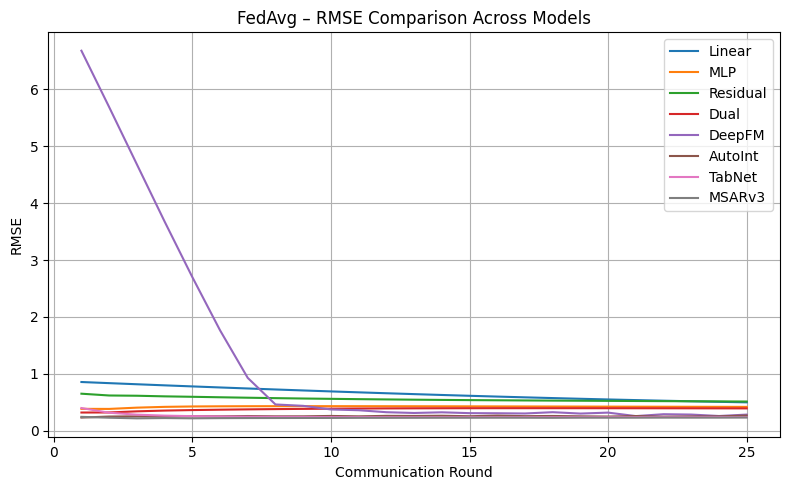

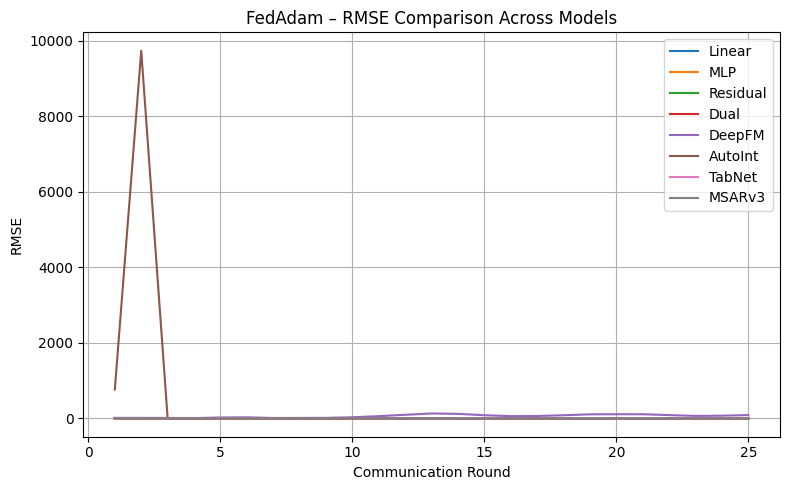

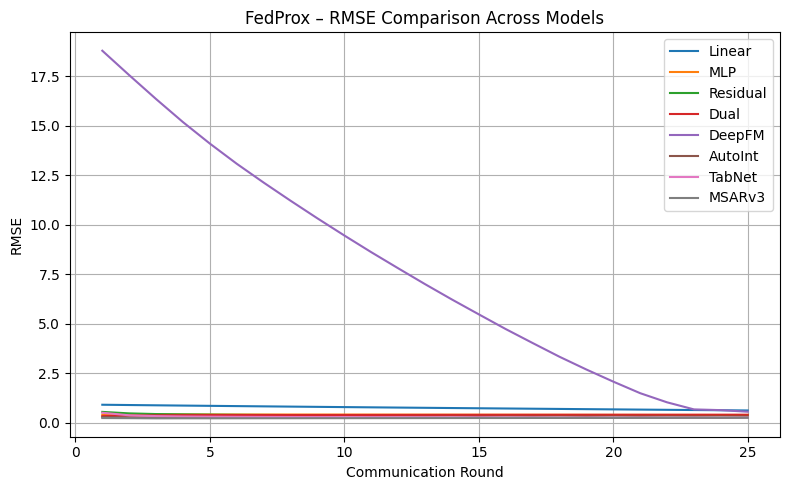

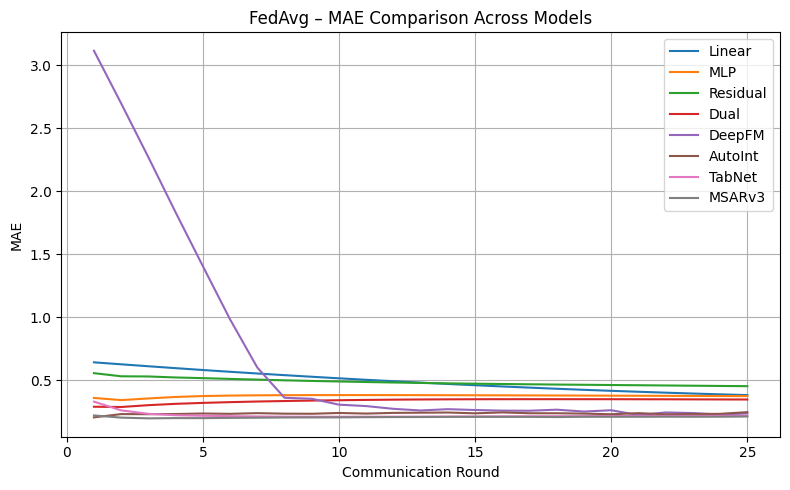

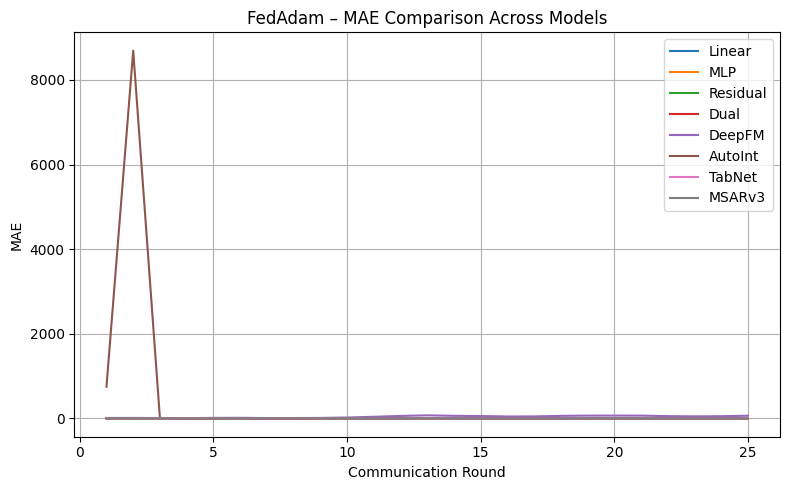

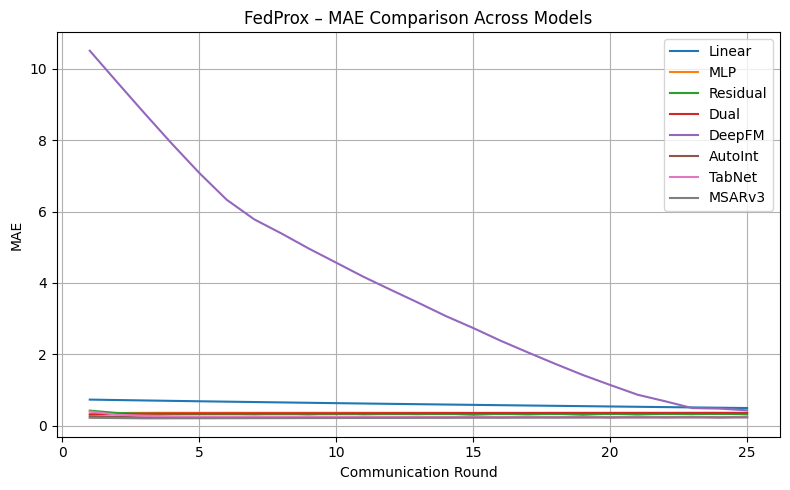

In [6]:
def process_federated(df):
    return df[["round", "mae", "rmse", "r2"]]

fed_std = {
    strat: {
        model: process_federated(df)
        for model, df in models.items()
    }
    for strat, models in fed_results.items()
}
for strat, models in fed_std.items():
    plt.figure(figsize=(8,5))

    for model, df in models.items():
        plt.plot(df["round"], df["rmse"], label=model)

    plt.xlabel("Communication Round")
    plt.ylabel("RMSE")
    plt.title(f"{strat} – RMSE Comparison Across Models")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
for strat, models in fed_std.items():
    plt.figure(figsize=(8,5))

    for model, df in models.items():
        plt.plot(df["round"], df["mae"], label=model)

    plt.xlabel("Communication Round")
    plt.ylabel("MAE")
    plt.title(f"{strat} – MAE Comparison Across Models")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [7]:
import os
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/Fs"
FL_BASE = os.path.join(BASE_PATH, "FL_Results_1")

all_dfs = []

# Loop through algorithms (FedAvg, FedProx, FedAdam)
for algo_name in os.listdir(FL_BASE):
    algo_path = os.path.join(FL_BASE, algo_name)

    if not os.path.isdir(algo_path):
        continue

    # Loop through model CSV files
    for file in os.listdir(algo_path):
        if file.endswith(".csv"):

            file_path = os.path.join(algo_path, file)
            df = pd.read_csv(file_path)

            # Extract model name (remove algo name + .csv)
            model_name = file.replace(algo_name, "").replace(".csv", "")

            # Add metadata columns
            df["algorithm"] = algo_name
            df["model"] = model_name

            all_dfs.append(df)

# Combine everything
combined_df = pd.concat(all_dfs, ignore_index=True)

# Reorder columns
combined_df = combined_df[["algorithm", "model", "round", "rmse", "mae", "r2"]]

# Save combined CSV
combined_path = os.path.join(FL_BASE, "Combined_FL_Results.csv")
combined_df.to_csv(combined_path, index=False)

print("✅ Combined FL results saved at:")
print(combined_path)


✅ Combined FL results saved at:
/content/drive/MyDrive/Fs/FL_Results_1/Combined_FL_Results.csv
